# Module 2 — Exploratory Data Analysis (EDA)
### House Prices: Advanced Regression Techniques (Ames, Iowa)

**Branch:** `hacao` · **Role:** Data Analyst · **Target:** `SalePrice` (regression)

This notebook follows the execution plan in [README.md](README.md). It covers **Steps 0–5 and 7** on the
Kaggle base dataset. **Step 6** (synthetic data from Module 1) is deferred until that data is delivered — the
notebook is written modularly so the synthetic block can be plugged in later.

**Deliverables produced by this notebook**
- `figures/*.png` — charts reused by Module 8 (report/slides)
- `outputs/missing_report.csv` → handoff to **Module 3** (cleaning)
- `outputs/outlier_candidates.csv` → handoff to **Module 3**
- `outputs/correlation_top.csv` → handoff to **Module 4** (feature engineering)
- `outputs/collinear_pairs.csv` → handoff to **Module 4**
- `outputs/eda_summary.json` → machine-readable digest of all key findings

> **Guiding principle (from the brief):** *every chart must lead to a business-meaningful insight.*

---
## Step 0 — Setup & load

Import libraries, configure a consistent chart style, resolve paths (works whether the notebook is run from
the repo root or from `EDA/`), and load `train.csv`.

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 140
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.titleweight'] = 'bold'

# --- Resolve paths (run from repo root OR from EDA/) ---
if os.path.exists('data/train.csv'):
    ROOT, EDA_DIR = '.', 'EDA'
elif os.path.exists('../data/train.csv'):
    ROOT, EDA_DIR = '..', '.'
else:
    raise FileNotFoundError('Cannot locate data/train.csv')

DATA_PATH = f'{ROOT}/data/train.csv'
FIG_DIR   = f'{EDA_DIR}/figures'
OUT_DIR   = f'{EDA_DIR}/outputs'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(f'{FIG_DIR}/{name}', bbox_inches='tight')
    print(f'  saved -> {FIG_DIR}/{name}')

SUMMARY = {}   # accumulates all key findings -> outputs/eda_summary.json
print('Setup complete. ROOT =', ROOT, '| figures ->', FIG_DIR, '| outputs ->', OUT_DIR)

Setup complete. ROOT = .. | figures -> ./figures | outputs -> ./outputs


In [2]:
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape, '=>', df.shape[0], 'rows x', df.shape[1], 'columns')
SUMMARY['n_rows'], SUMMARY['n_cols'] = int(df.shape[0]), int(df.shape[1])
df.head()

Dataset shape: (1460, 81) => 1460 rows x 81 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 0.1 Classify columns

Distinguishing **numeric**, **categorical (nominal)**, and **ordinal** columns up front prevents mistakes later
(e.g. treating a quality rating as a plain number, or `MSSubClass` — a numeric *code* — as a continuous value).

In [3]:
id_col, target = 'Id', 'SalePrice'
numeric_all   = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_feats = [c for c in numeric_all if c not in (id_col, target)]
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns (incl. Id & target): {len(numeric_all)}')
print(f'Numeric feature columns            : {len(numeric_feats)}')
print(f'Categorical (object) columns       : {len(categorical_cols)}')
print('\nNOTE: MSSubClass is numeric-coded but semantically CATEGORICAL (dwelling class).')
SUMMARY['n_numeric']     = len(numeric_feats)
SUMMARY['n_categorical'] = len(categorical_cols)

Numeric columns (incl. Id & target): 38
Numeric feature columns            : 36
Categorical (object) columns       : 43

NOTE: MSSubClass is numeric-coded but semantically CATEGORICAL (dwelling class).


### 0.2 Encode ordinal (quality/condition) columns

Many columns are **ordinal** — `Ex > Gd > TA > Fa > Po`. Encoding them to numbers (with **0 = absent/none**,
since `NA` here means "the feature does not exist") lets them participate in the correlation analysis, where
several turn out to be among the strongest price drivers. This mapping is also a direct hint for Module 4.

In [4]:
QUAL5 = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1}
qual_always = ['ExterQual','ExterCond','HeatingQC','KitchenQual']                     # always present
qual_na     = ['BsmtQual','BsmtCond','FireplaceQu','GarageQual','GarageCond','PoolQC'] # NA = absent -> 0
BSMT_EXP   = {'Gd':4,'Av':3,'Mn':2,'No':1}
BSMT_FIN   = {'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1}
GARAGE_FIN = {'Fin':3,'RFn':2,'Unf':1}
FUNCTIONAL = {'Typ':8,'Min1':7,'Min2':6,'Mod':5,'Maj1':4,'Maj2':3,'Sev':2,'Sal':1}

df_enc = df.copy()
for c in qual_always + qual_na:
    df_enc[c] = df_enc[c].map(QUAL5).fillna(0)
df_enc['BsmtExposure'] = df_enc['BsmtExposure'].map(BSMT_EXP).fillna(0)
df_enc['BsmtFinType1'] = df_enc['BsmtFinType1'].map(BSMT_FIN).fillna(0)
df_enc['BsmtFinType2'] = df_enc['BsmtFinType2'].map(BSMT_FIN).fillna(0)
df_enc['GarageFinish'] = df_enc['GarageFinish'].map(GARAGE_FIN).fillna(0)
df_enc['Functional']   = df_enc['Functional'].map(FUNCTIONAL).fillna(FUNCTIONAL['Typ'])

encoded_ordinals = qual_always + qual_na + ['BsmtExposure','BsmtFinType1','BsmtFinType2',
                                            'GarageFinish','Functional']
print('Encoded', len(encoded_ordinals), 'ordinal columns to numeric (0 = absent/none):')
print(encoded_ordinals)

Encoded 15 ordinal columns to numeric (0 = absent/none):
['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual', 'BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Functional']


---
## Step 1 — Target variable: `SalePrice`

Understand the shape of what we are predicting. We check the raw distribution, its **skewness/kurtosis**, the
effect of a **log transform**, and a **Q-Q plot** for normality.

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0

Skewness (raw)   :  1.883   (>0 => right-skewed)
Kurtosis (raw)   :  6.536   (>0 => heavy tails)
Skewness (log1p) :  0.121   (closer to 0 => more normal)


  saved -> ./figures/01_saleprice_distribution.png


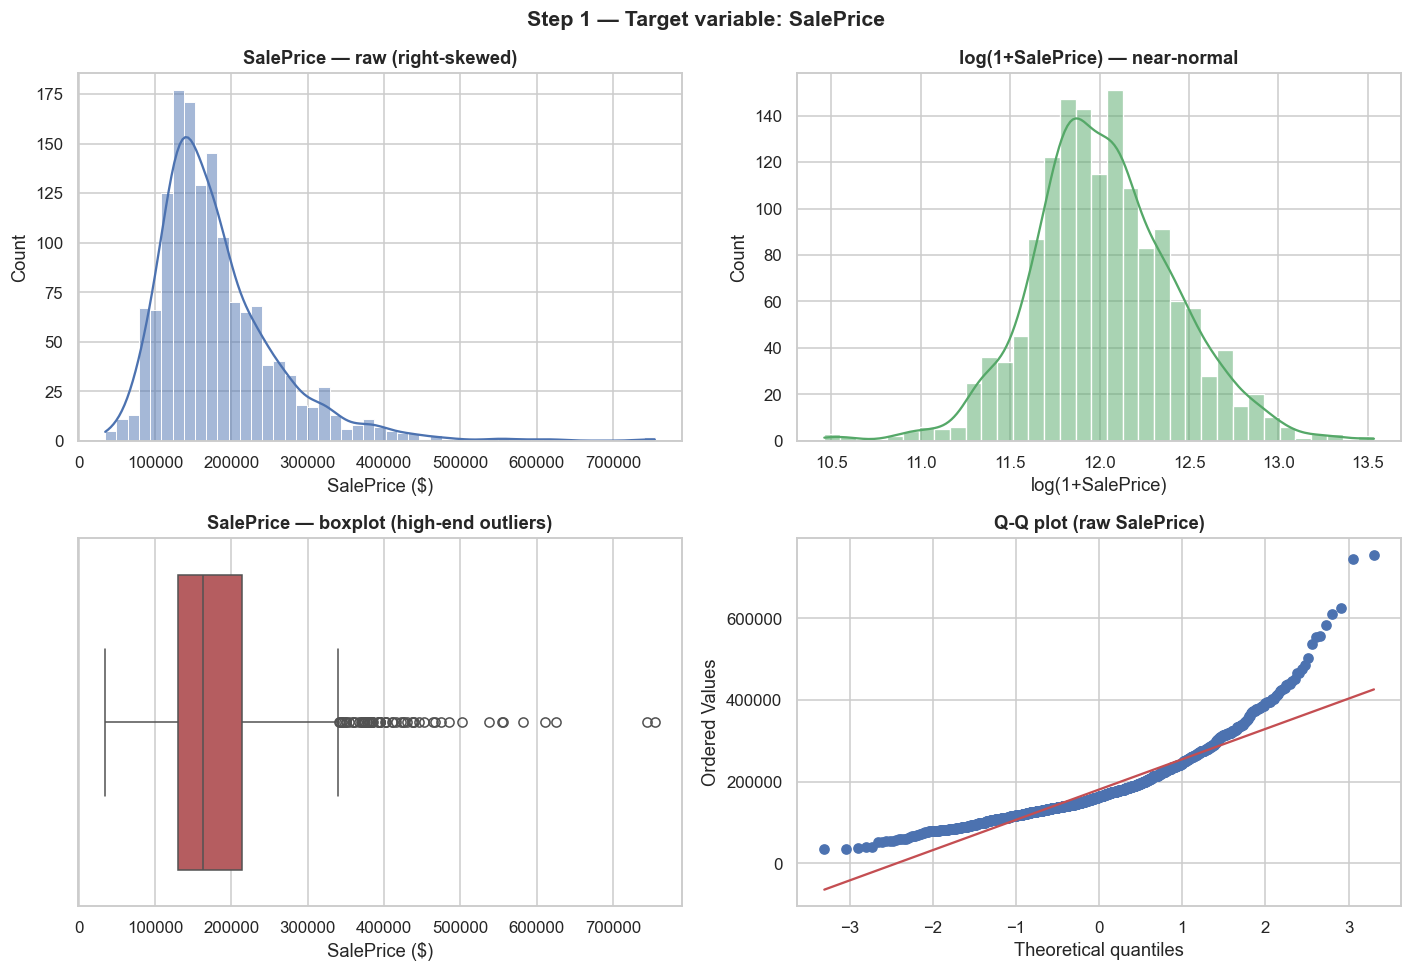

In [5]:
sp = df['SalePrice']
skew_raw, kurt_raw = sp.skew(), sp.kurt()
skew_log = np.log1p(sp).skew()

print(sp.describe().round(0).to_string())
print(f'\nSkewness (raw)   : {skew_raw:6.3f}   (>0 => right-skewed)')
print(f'Kurtosis (raw)   : {kurt_raw:6.3f}   (>0 => heavy tails)')
print(f'Skewness (log1p) : {skew_log:6.3f}   (closer to 0 => more normal)')

SUMMARY['saleprice'] = {
    'min': float(sp.min()), 'max': float(sp.max()),
    'mean': float(sp.mean()), 'median': float(sp.median()),
    'skew_raw': float(skew_raw), 'skew_log': float(skew_log), 'kurtosis_raw': float(kurt_raw),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(sp, kde=True, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('SalePrice — raw (right-skewed)'); axes[0,0].set_xlabel('SalePrice ($)')

sns.histplot(np.log1p(sp), kde=True, ax=axes[0,1], color='#55A868')
axes[0,1].set_title('log(1+SalePrice) — near-normal'); axes[0,1].set_xlabel('log(1+SalePrice)')

sns.boxplot(x=sp, ax=axes[1,0], color='#C44E52')
axes[1,0].set_title('SalePrice — boxplot (high-end outliers)'); axes[1,0].set_xlabel('SalePrice ($)')

stats.probplot(sp, plot=axes[1,1])
axes[1,1].set_title('Q-Q plot (raw SalePrice)')

fig.suptitle('Step 1 — Target variable: SalePrice', fontsize=14, fontweight='bold')
fig.tight_layout()
savefig('01_saleprice_distribution.png')
plt.show()

> **Insight → Modules 4/5:** `SalePrice` is strongly right-skewed. A `log`-transform brings it close to normal
> (skew drops from ~1.9 to ~0.1), which stabilises variance and improves linear-model performance. **Use
> `log(SalePrice)` as the modelling target.**

---
## Step 2 — Missing values

We rank columns by % missing and, crucially, separate two very different cases:
- **`NA` = feature absent** (e.g. `PoolQC`, `Alley`, `FireplaceQu`, all `Bsmt*`/`Garage*`) → fill with `"None"`/`0`.
- **Genuine missing** (e.g. `LotFrontage`, `Electrical`) → needs real imputation.

This distinction is the key handoff to Module 3.

Columns with missing values: 19

      column  n_missing  pct_missing                           na_meaning
      PoolQC       1453        99.52 absent (NA = feature does not exist)
 MiscFeature       1406        96.30 absent (NA = feature does not exist)
       Alley       1369        93.77 absent (NA = feature does not exist)
       Fence       1179        80.75 absent (NA = feature does not exist)
  MasVnrType        872        59.73 absent (NA = feature does not exist)
 FireplaceQu        690        47.26 absent (NA = feature does not exist)
 LotFrontage        259        17.74   genuine missing (needs imputation)
  GarageType         81         5.55 absent (NA = feature does not exist)
 GarageYrBlt         81         5.55 absent (NA = feature does not exist)
GarageFinish         81         5.55 absent (NA = feature does not exist)
  GarageQual         81         5.55 absent (NA = feature does not exist)
  GarageCond         81         5.55 absent (NA = feature does not exist)
BsmtE

  saved -> ./figures/02_missing_values.png


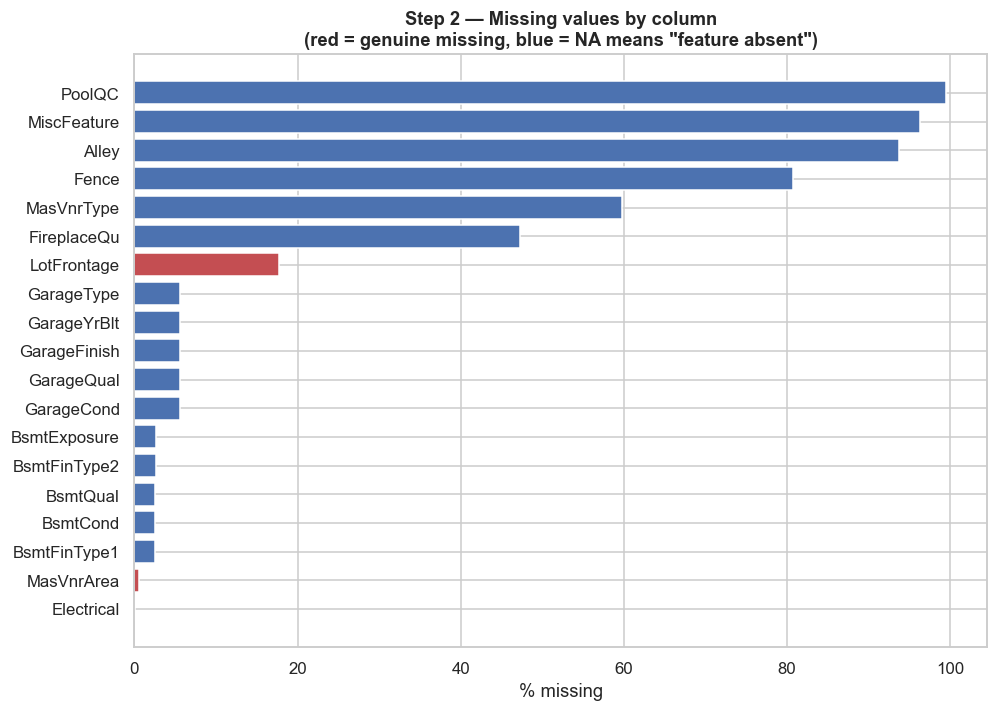

In [6]:
NA_ABSENT = {'Alley','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','PoolQC',
             'Fence','MiscFeature','MasVnrType','GarageYrBlt'}

miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)

def na_meaning(col):
    return 'absent (NA = feature does not exist)' if col in NA_ABSENT else 'genuine missing (needs imputation)'

missing_report = pd.DataFrame({
    'column': miss.index,
    'n_missing': miss.values.astype(int),
    'pct_missing': miss_pct.values,
    'na_meaning': [na_meaning(c) for c in miss.index],
})
print(f'Columns with missing values: {len(missing_report)}\n')
print(missing_report.to_string(index=False))

missing_report.to_csv(f'{OUT_DIR}/missing_report.csv', index=False)
print(f'\n-> saved {OUT_DIR}/missing_report.csv')
SUMMARY['missing'] = {
    'n_cols_with_missing': int(len(missing_report)),
    'n_genuine': int((~missing_report['column'].isin(NA_ABSENT)).sum()),
    'top': missing_report.head(8).to_dict('records'),
}

plt.figure(figsize=(10, 7))
colors = ['#C44E52' if na_meaning(c).startswith('genuine') else '#4C72B0' for c in missing_report['column']]
plt.barh(missing_report['column'][::-1], missing_report['pct_missing'][::-1], color=colors[::-1])
plt.xlabel('% missing')
plt.title('Step 2 — Missing values by column\n(red = genuine missing, blue = NA means "feature absent")')
savefig('02_missing_values.png')
plt.show()

> **Insight → Module 3:** A handful of columns are almost entirely `NA` (`PoolQC`, `MiscFeature`, `Alley`,
> `Fence`, `FireplaceQu`) — but that `NA` encodes *"no pool / no alley / no fireplace"*, **not** a data-quality
> problem. Only a few columns (led by `LotFrontage`, plus a single `Electrical` row) are genuinely missing and
> need imputation. See `outputs/missing_report.csv`.

---
## Step 3 — Numeric variables & outliers

Profile the key numeric features, then use the classic **`GrLivArea` vs `SalePrice`** scatter to catch the two
well-known Ames outliers (very large homes sold cheaply).

  saved -> ./figures/03_numeric_distributions.png


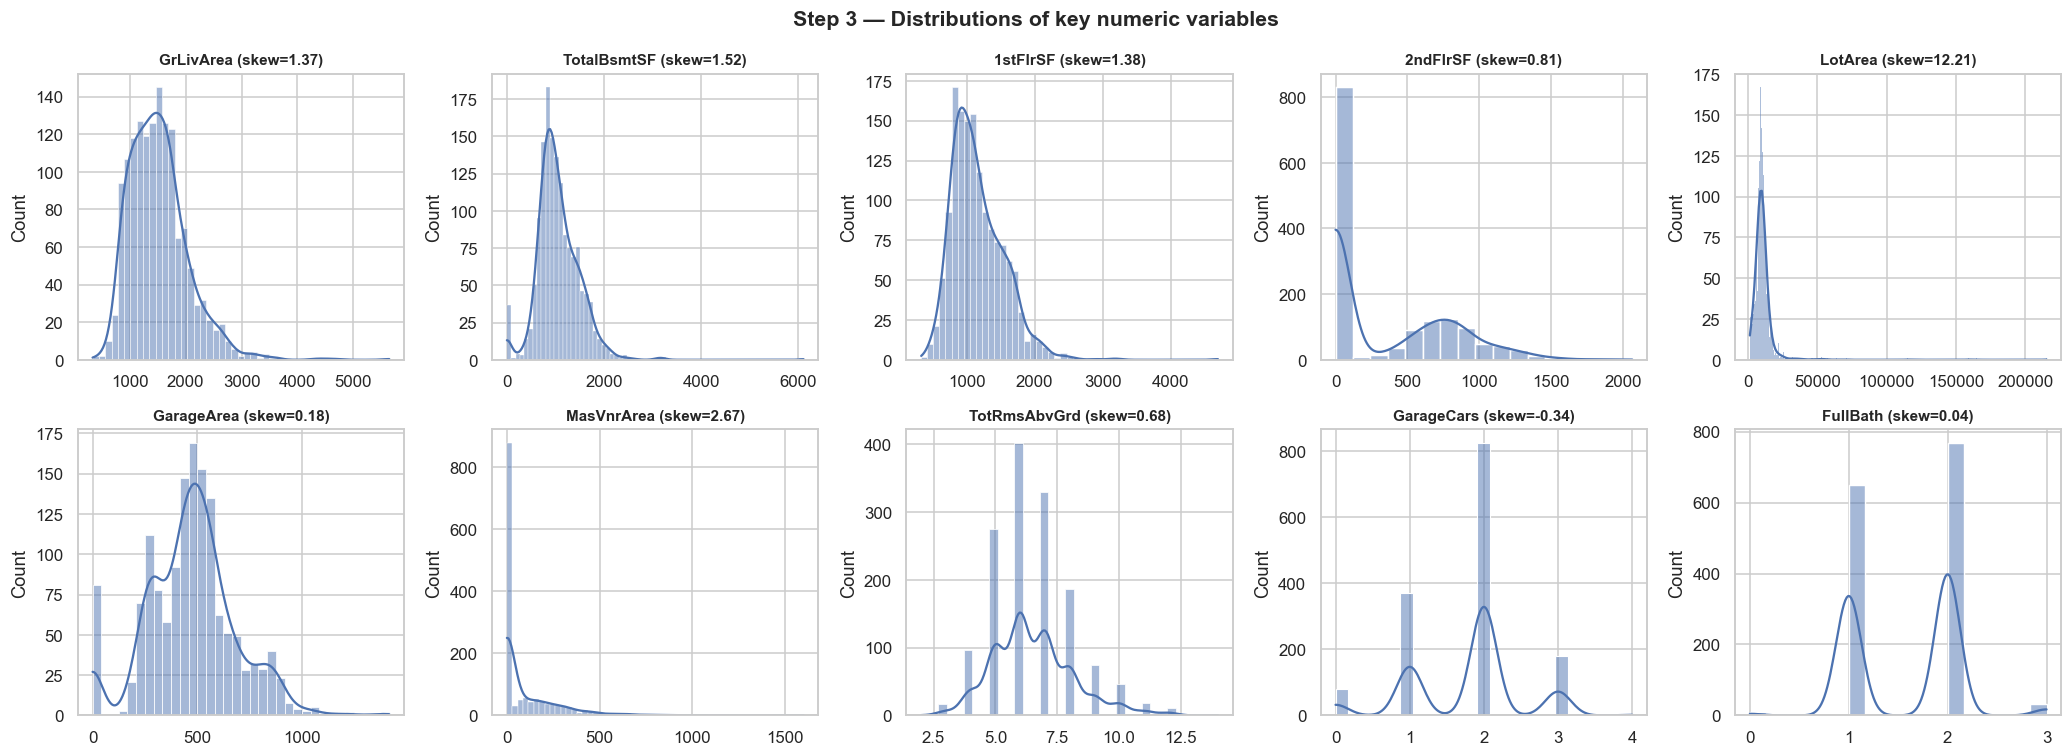

In [7]:
key_num = ['GrLivArea','TotalBsmtSF','1stFlrSF','2ndFlrSF','LotArea','GarageArea',
           'MasVnrArea','TotRmsAbvGrd','GarageCars','FullBath']
fig, axes = plt.subplots(2, 5, figsize=(19, 7))
for ax, col in zip(axes.ravel(), key_num):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'{col} (skew={df[col].skew():.2f})', fontsize=10)
    ax.set_xlabel('')
fig.suptitle('Step 3 — Distributions of key numeric variables', fontsize=14, fontweight='bold')
fig.tight_layout()
savefig('03_numeric_distributions.png')
plt.show()

  saved -> ./figures/03_grlivarea_vs_saleprice.png


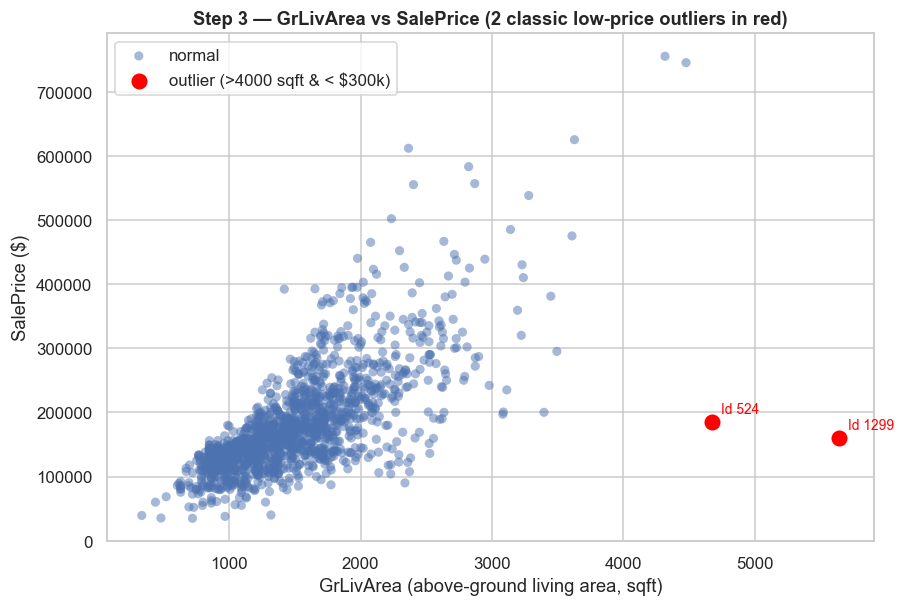

Outlier candidates (handoff -> Module 3):
  Id  GrLivArea  SalePrice  OverallQual Neighborhood SaleCondition                                                  reason
 524       4676     184750           10      Edwards       Partial GrLivArea>4000 & SalePrice<300k (high-leverage outlier)
1299       5642     160000           10      Edwards       Partial GrLivArea>4000 & SalePrice<300k (high-leverage outlier)

-> saved ./outputs/outlier_candidates.csv


In [8]:
# GrLivArea vs SalePrice — classic Ames outliers: huge homes (>4000 sqft) sold cheaply
out_mask = (df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)
outliers = df.loc[out_mask, ['Id','GrLivArea','SalePrice','OverallQual','Neighborhood','SaleCondition']]

plt.figure(figsize=(9, 6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, edgecolor='none', label='normal')
plt.scatter(df.loc[out_mask,'GrLivArea'], df.loc[out_mask,'SalePrice'],
            color='red', s=90, label='outlier (>4000 sqft & < $300k)')
for _, r in outliers.iterrows():
    plt.annotate(f'Id {int(r.Id)}', (r.GrLivArea, r.SalePrice),
                 textcoords='offset points', xytext=(6,6), color='red', fontsize=9)
plt.xlabel('GrLivArea (above-ground living area, sqft)')
plt.ylabel('SalePrice ($)')
plt.title('Step 3 — GrLivArea vs SalePrice (2 classic low-price outliers in red)')
plt.legend()
savefig('03_grlivarea_vs_saleprice.png')
plt.show()

cand = outliers.copy()
cand['reason'] = 'GrLivArea>4000 & SalePrice<300k (high-leverage outlier)'
cand.to_csv(f'{OUT_DIR}/outlier_candidates.csv', index=False)
print('Outlier candidates (handoff -> Module 3):')
print(cand.to_string(index=False))
print(f'\n-> saved {OUT_DIR}/outlier_candidates.csv')
SUMMARY['outliers'] = {'ids': [int(x) for x in outliers['Id'].tolist()],
                       'detail': cand.to_dict('records')}

> **Insight → Module 3:** The two flagged homes (`Id 524`, `Id 1299`) have the largest living areas in the
> dataset yet sold far below trend — both are `Partial` sales (incomplete when assessed). They exert strong
> leverage on any linear fit and should be **removed or down-weighted** before modelling. See
> `outputs/outlier_candidates.csv`.

---
## Step 4 — Correlation & multicollinearity

We rank features by correlation with `SalePrice` (numeric **and** encoded-ordinal), plot a focused heatmap of
the top drivers, then list **multicollinear predictor pairs** and a preliminary **VIF** — both critical inputs
for feature selection in Module 4.

Top 15 features correlated with SalePrice:
OverallQual     0.791
GrLivArea       0.709
ExterQual       0.683
KitchenQual     0.660
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
BsmtQual        0.585
FullBath        0.561
GarageFinish    0.549
TotRmsAbvGrd    0.534
YearBuilt       0.523
FireplaceQu     0.520
YearRemodAdd    0.507

-> saved ./outputs/correlation_top.csv (51 features)


  saved -> ./figures/04_correlation_heatmap.png


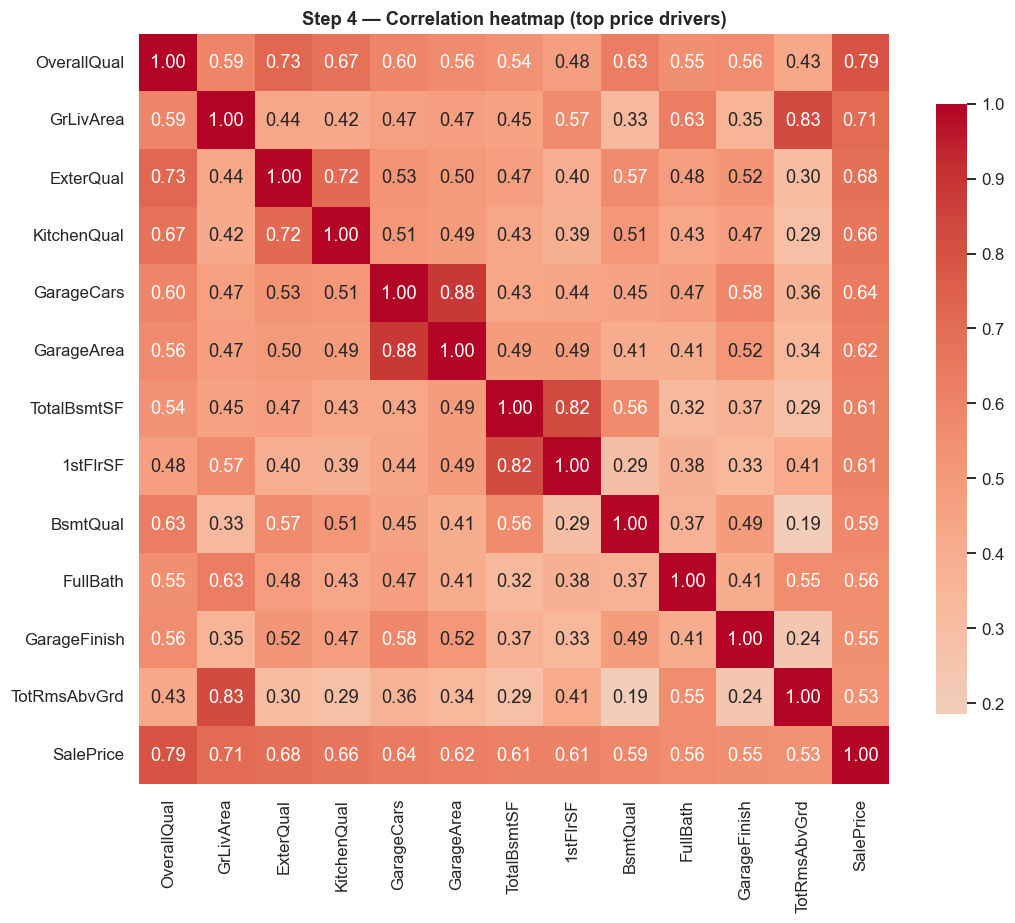

  saved -> ./figures/04_top_correlations.png


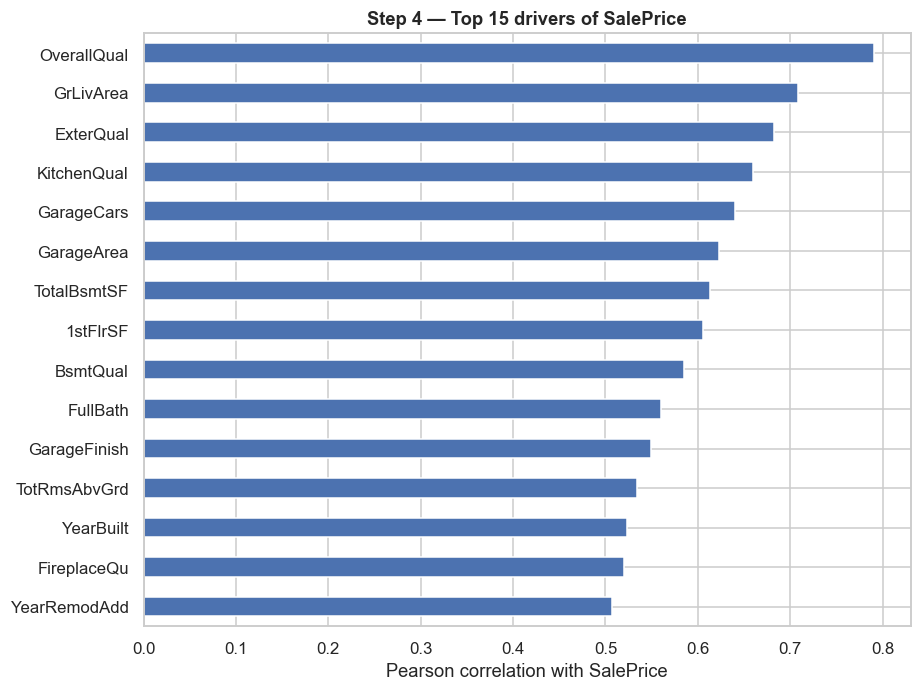

In [9]:
corr_cols = numeric_feats + encoded_ordinals
corr_df   = df_enc[corr_cols + ['SalePrice']].corr()

corr_target = corr_df['SalePrice'].drop('SalePrice').sort_values(ascending=False)
top_corr = corr_target.head(15)
print('Top 15 features correlated with SalePrice:')
print(top_corr.round(3).to_string())

corr_out = corr_target.reset_index()
corr_out.columns = ['feature', 'corr_with_saleprice']
corr_out = corr_out.reindex(corr_out['corr_with_saleprice'].abs().sort_values(ascending=False).index)
corr_out.to_csv(f'{OUT_DIR}/correlation_top.csv', index=False)
print(f'\n-> saved {OUT_DIR}/correlation_top.csv ({len(corr_out)} features)')
SUMMARY['top_corr'] = top_corr.round(3).to_dict()

top_feats = top_corr.head(12).index.tolist() + ['SalePrice']
plt.figure(figsize=(11, 9))
sns.heatmap(df_enc[top_feats].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={'shrink': .8})
plt.title('Step 4 — Correlation heatmap (top price drivers)')
savefig('04_correlation_heatmap.png')
plt.show()

plt.figure(figsize=(9, 7))
top_corr.sort_values().plot(kind='barh', color='#4C72B0')
plt.xlabel('Pearson correlation with SalePrice')
plt.title('Step 4 — Top 15 drivers of SalePrice')
savefig('04_top_correlations.png')
plt.show()

In [10]:
# Multicollinear predictor pairs (|corr| >= 0.70)
pred_corr = df_enc[corr_cols].corr().abs()
cols = pred_corr.columns
pairs = [(cols[i], cols[j], round(float(pred_corr.iloc[i, j]), 3))
         for i in range(len(cols)) for j in range(i+1, len(cols))
         if pred_corr.iloc[i, j] >= 0.70]
collinear = pd.DataFrame(sorted(pairs, key=lambda x: -x[2]),
                         columns=['feature_1','feature_2','abs_corr'])
print('Multicollinear predictor pairs (|corr| >= 0.70):')
print(collinear.to_string(index=False) if len(collinear) else '(none)')
collinear.to_csv(f'{OUT_DIR}/collinear_pairs.csv', index=False)
print(f'\n-> saved {OUT_DIR}/collinear_pairs.csv')
SUMMARY['collinear_pairs'] = collinear.to_dict('records')

# Preliminary VIF via diagonal of the inverse correlation matrix (>5 => concerning)
vif_feats = ['GrLivArea','TotalBsmtSF','1stFlrSF','2ndFlrSF','GarageArea','GarageCars',
             'TotRmsAbvGrd','FullBath','YearBuilt','OverallQual']
try:
    cmat = df_enc[vif_feats].corr().values
    vif = pd.Series(np.diag(np.linalg.inv(cmat)), index=vif_feats).sort_values(ascending=False)
    print('\nPreliminary VIF (>5 => concerning):')
    print(vif.round(2).to_string())
    SUMMARY['vif'] = vif.round(2).to_dict()
except Exception as e:
    print('VIF skipped:', e)

Multicollinear predictor pairs (|corr| >= 0.70):
  feature_1    feature_2  abs_corr
 GarageQual   GarageCond     0.959
   PoolArea       PoolQC     0.937
 GarageCars   GarageArea     0.882
 Fireplaces  FireplaceQu     0.863
  YearBuilt  GarageYrBlt     0.826
  GrLivArea TotRmsAbvGrd     0.825
TotalBsmtSF     1stFlrSF     0.820
 BsmtFinSF2 BsmtFinType2     0.789
OverallQual    ExterQual     0.726
  ExterQual  KitchenQual     0.716

-> saved ./outputs/collinear_pairs.csv

Preliminary VIF (>5 => concerning):
GrLivArea       125.64
2ndFlrSF         87.11
1stFlrSF         70.20
GarageCars        5.27
GarageArea        4.93
TotalBsmtSF       3.60
TotRmsAbvGrd      3.36
OverallQual       2.59
FullBath          2.19
YearBuilt         2.12


> **Insight → Module 4:** The strongest drivers are **`OverallQual`**, **`GrLivArea`**, plus the quality group
> (`ExterQual`, `KitchenQual`, `BsmtQual`) and the garage/basement size group. Several pairs are highly
> collinear — notably **`GarageCars ↔ GarageArea`**, **`TotalBsmtSF ↔ 1stFlrSF`**, **`GrLivArea ↔ TotRmsAbvGrd`**,
> **`YearBuilt ↔ GarageYrBlt`**. Keep one per pair (or build a combined feature) to avoid unstable coefficients.

---
## Step 5 — Categorical variables & group comparisons

Compare `SalePrice` across **location** (`Neighborhood`), **property type** (`BldgType`, `HouseStyle`),
**age**, and **overall quality** — the comparisons the brief explicitly asks for.

  saved -> ./figures/05_saleprice_by_neighborhood.png


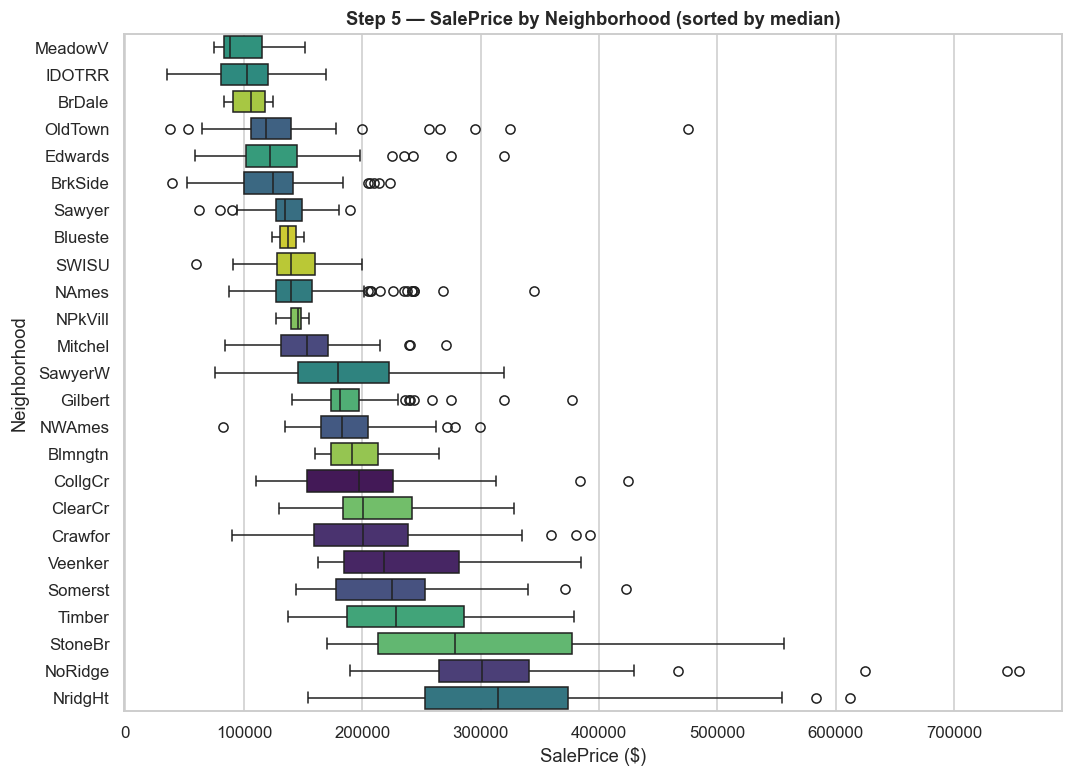

Most expensive (median):
 Neighborhood
Somerst    225500.0
Timber     228475.0
StoneBr    278000.0
NoRidge    301500.0
NridgHt    315000.0

Cheapest (median):
 Neighborhood
MeadowV     88000.0
IDOTRR     103000.0
BrDale     106000.0
OldTown    119000.0
Edwards    121750.0

Ratio richest/poorest median = 3.58x


In [11]:
# 5a — SalePrice by Neighborhood
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
plt.figure(figsize=(11, 8))
sns.boxplot(data=df, x='SalePrice', y='Neighborhood', order=order,
            hue='Neighborhood', palette='viridis', legend=False)
plt.title('Step 5 — SalePrice by Neighborhood (sorted by median)')
plt.xlabel('SalePrice ($)')
savefig('05_saleprice_by_neighborhood.png')
plt.show()

nbhd_med = df.groupby('Neighborhood')['SalePrice'].median().sort_values()
ratio = nbhd_med.max() / nbhd_med.min()
print('Most expensive (median):\n', nbhd_med.tail(5).round(0).to_string())
print('\nCheapest (median):\n', nbhd_med.head(5).round(0).to_string())
print(f'\nRatio richest/poorest median = {ratio:.2f}x')
SUMMARY['neighborhood'] = {'top5': nbhd_med.tail(5).round(0).to_dict(),
                           'bottom5': nbhd_med.head(5).round(0).to_dict(),
                           'ratio_max_min': float(round(ratio, 2))}

  saved -> ./figures/05_saleprice_by_property_type.png


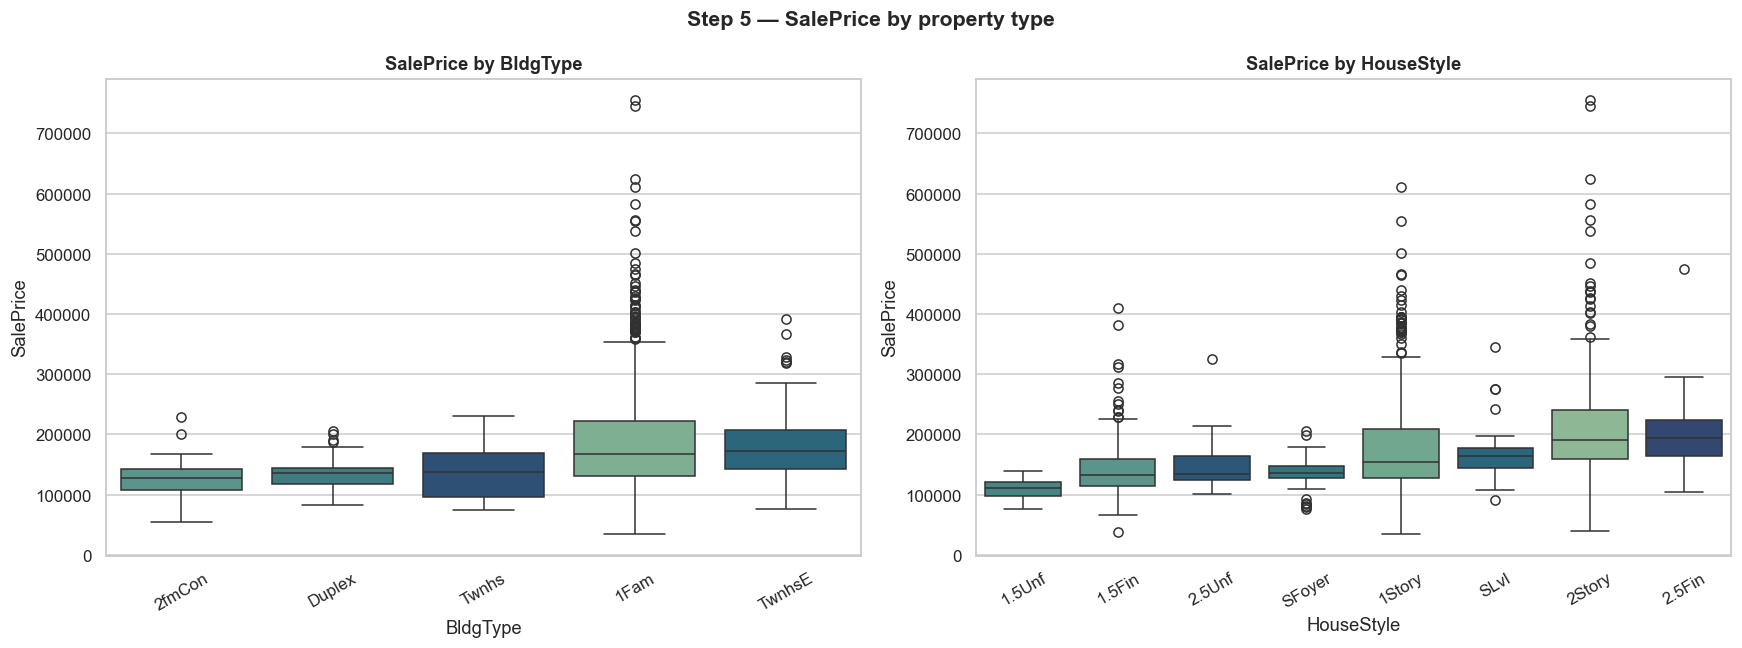

In [12]:
# 5b — SalePrice by property type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col in zip(axes, ['BldgType','HouseStyle']):
    o = df.groupby(col)['SalePrice'].median().sort_values().index
    sns.boxplot(data=df, x=col, y='SalePrice', order=o, hue=col, palette='crest', legend=False, ax=ax)
    ax.set_title(f'SalePrice by {col}'); ax.tick_params(axis='x', rotation=30)
fig.suptitle('Step 5 — SalePrice by property type', fontsize=14, fontweight='bold')
fig.tight_layout()
savefig('05_saleprice_by_property_type.png')
plt.show()

  saved -> ./figures/05_saleprice_vs_age.png


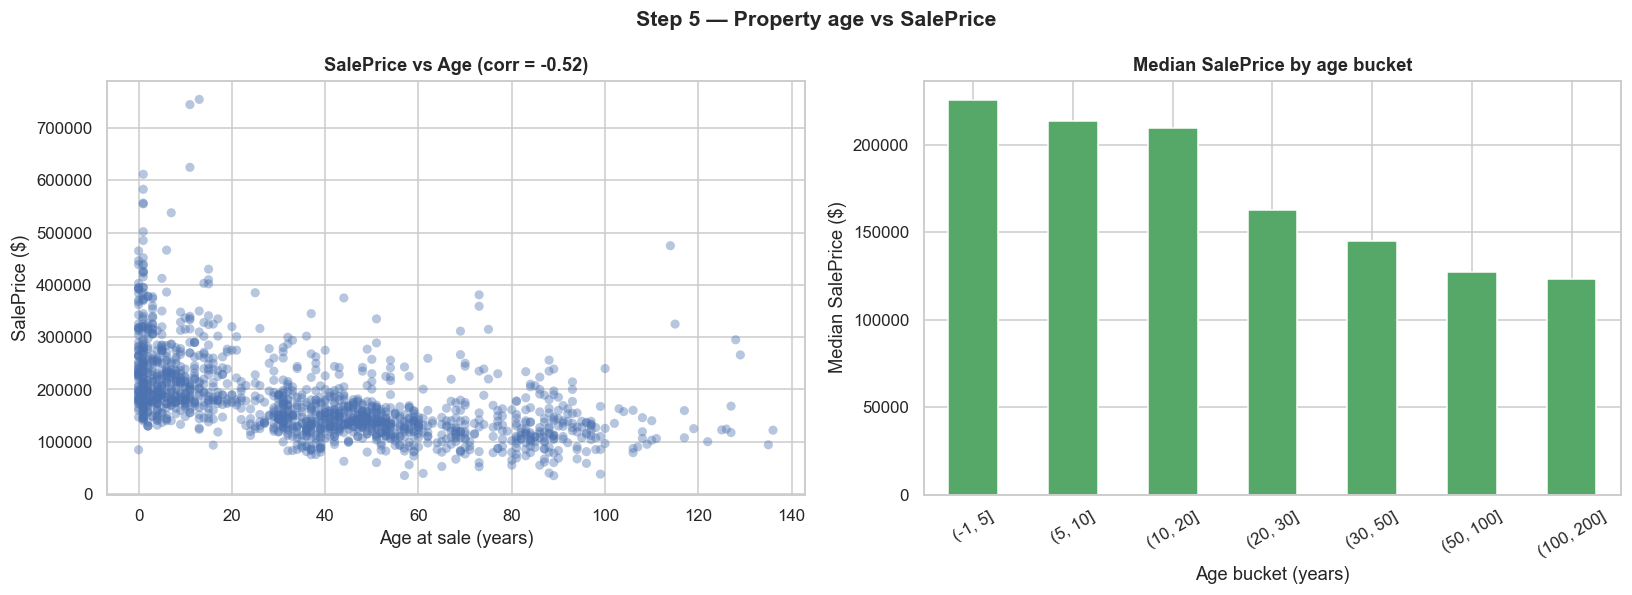

Correlation Age vs SalePrice = -0.523 (older -> generally cheaper)


In [13]:
# 5c — SalePrice vs property age
df['Age'] = df['YrSold'] - df['YearBuilt']
corr_age = df['Age'].corr(df['SalePrice'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].scatter(df['Age'], df['SalePrice'], alpha=0.4, edgecolor='none')
axes[0].set_xlabel('Age at sale (years)'); axes[0].set_ylabel('SalePrice ($)')
axes[0].set_title(f'SalePrice vs Age (corr = {corr_age:.2f})')

bins = pd.cut(df['Age'], bins=[-1,5,10,20,30,50,100,200])
df.groupby(bins, observed=True)['SalePrice'].median().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_xlabel('Age bucket (years)'); axes[1].set_ylabel('Median SalePrice ($)')
axes[1].set_title('Median SalePrice by age bucket'); axes[1].tick_params(axis='x', rotation=30)
fig.suptitle('Step 5 — Property age vs SalePrice', fontsize=14, fontweight='bold')
fig.tight_layout()
savefig('05_saleprice_vs_age.png')
plt.show()
print(f'Correlation Age vs SalePrice = {corr_age:.3f} (older -> generally cheaper)')
SUMMARY['age_corr'] = float(round(corr_age, 3))

  saved -> ./figures/05_saleprice_by_overallqual.png


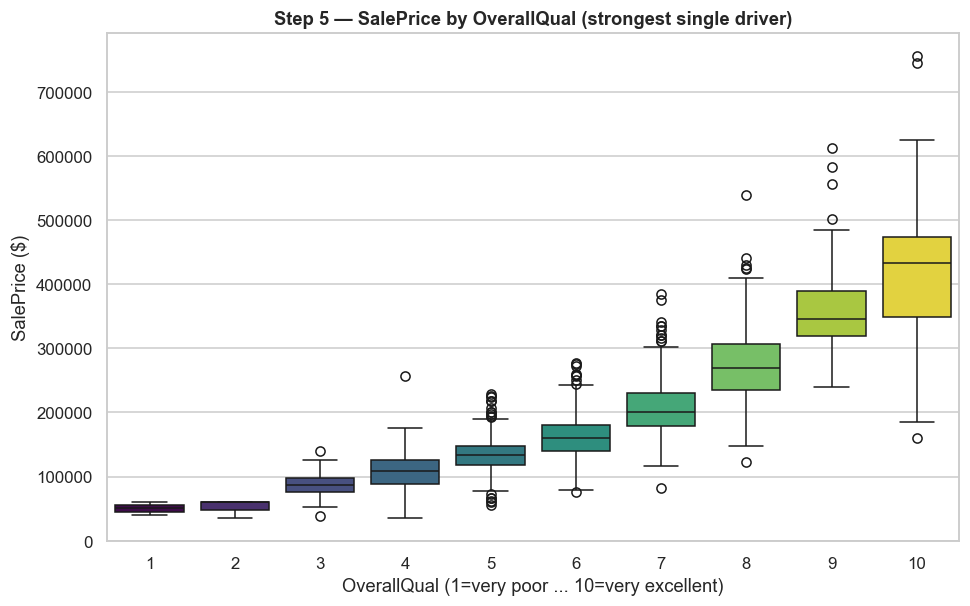

Median SalePrice by OverallQual:
OverallQual
1      50150.0
2      60000.0
3      86250.0
4     108000.0
5     133000.0
6     160000.0
7     200141.0
8     269750.0
9     345000.0
10    432390.0


In [14]:
# 5d — SalePrice by OverallQual (strongest single driver)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='OverallQual', y='SalePrice', hue='OverallQual', palette='viridis', legend=False)
plt.title('Step 5 — SalePrice by OverallQual (strongest single driver)')
plt.xlabel('OverallQual (1=very poor ... 10=very excellent)'); plt.ylabel('SalePrice ($)')
savefig('05_saleprice_by_overallqual.png')
plt.show()
q_med = df.groupby('OverallQual')['SalePrice'].median()
print('Median SalePrice by OverallQual:')
print(q_med.round(0).to_string())
SUMMARY['overallqual_median'] = {int(k): float(v) for k, v in q_med.round(0).items()}

> **Insight → Modules 4/8:** Location and quality dominate. The most expensive neighborhoods (`NoRidge`,
> `NridgHt`, `StoneBr`) have median prices ~3× the cheapest (`MeadowV`, `IDOTRR`). Price rises steeply and
> non-linearly with `OverallQual`, and declines with age. `Neighborhood` and `OverallQual` are must-keep
> features; consider a derived `Age` feature.

---
## Step 7 — Synthesis & handoff

Write the machine-readable digest and confirm the handoff files. The written narrative lives in
[EDA_FINDINGS.md](EDA_FINDINGS.md).

> **Step 6 (synthetic data)** is intentionally not run here — it depends on Module 1's deliverable. When that
> data arrives, add a new section that (a) checks the plausibility of the synthetic distributions and
> (b) plots `SalePrice` vs distance-to-amenities, then re-run this notebook.

In [15]:
SUMMARY['handoff_files'] = {
    'missing_report.csv':     'columns with missing values + NA-meaning  (-> Module 3)',
    'outlier_candidates.csv': 'high-leverage outliers to review          (-> Module 3)',
    'correlation_top.csv':    'features ranked by |corr| with SalePrice  (-> Module 4)',
    'collinear_pairs.csv':    'predictor pairs with |corr| >= 0.70       (-> Module 4)',
}
with open(f'{OUT_DIR}/eda_summary.json', 'w', encoding='utf-8') as f:
    json.dump(SUMMARY, f, indent=2, ensure_ascii=False)

print('Saved outputs/eda_summary.json\n')
print('=== HANDOFF FILES ===')
for k, v in SUMMARY['handoff_files'].items():
    print(f'  outputs/{k:24s}: {v}')
print('\nEDA complete for the Kaggle base. Step 6 (synthetic data) pending Module 1 delivery.')

Saved outputs/eda_summary.json

=== HANDOFF FILES ===
  outputs/missing_report.csv      : columns with missing values + NA-meaning  (-> Module 3)
  outputs/outlier_candidates.csv  : high-leverage outliers to review          (-> Module 3)
  outputs/correlation_top.csv     : features ranked by |corr| with SalePrice  (-> Module 4)
  outputs/collinear_pairs.csv     : predictor pairs with |corr| >= 0.70       (-> Module 4)

EDA complete for the Kaggle base. Step 6 (synthetic data) pending Module 1 delivery.
